## Universidad Autónoma de Aguascalientes
## Departamento: Ciencias de la Computación
## Carrera: Ingeniería en Computación Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864)
## Semestre: Enero - Junio del 2026

---
# Fase 4: Sistema de Reconocimiento Facial en Tiempo Real

## Descripción del Proyecto

Este proyecto implementa un **pipeline completo de reconocimiento facial supervisado**.
A diferencia de las fases anteriores (síntesis GAN, clasificación de emociones), aquí la
tarea es de **identificación de identidad**: dado un rostro desconocido, determinar a cuál
de los sujetos registrados pertenece — o marcarlo como `DESCONOCIDO` si no pertenece a
ninguno.

---
## Objetivos

| # | Objetivo | Técnica |
|---|---|---|
| 1 | Carga y preprocesamiento del dataset | OpenCV, NumPy |
| 2 | Extracción de características faciales | LBP, HOG, PCA |
| 3 | Entrenamiento de múltiples modelos | LBPH, SVM, KNN, CNN |
| 4 | Comparativa objetiva de resultados | Accuracy, matrices de confusión |
| 5 | Demo en tiempo real con el mejor modelo | OpenCV VideoCapture |

---
## Arquitectura del Pipeline

```
  /reconocimiento_facial/
    ├── sujeto_1/  (N imágenes)
    └── sujeto_2/  (M imágenes)

         ↓  Preprocesamiento
  [Escala de grises · Normalización · Resize 128×128]

         ↓  Extracción de características
  ┌──────────────┬──────────────┬──────────────┐
  │ Píxeles raw  │   LBP hist.  │  HOG feat.   │
  └──────────────┴──────────────┴──────────────┘

         ↓  Modelos (entrenamiento y evaluación)
  ┌──────────┬────────┬─────┬──────────────────┐
  │  LBPH    │  SVM   │ KNN │  CNN (PyTorch)    │
  └──────────┴────────┴─────┴──────────────────┘

         ↓  Mejor modelo
  [Demo en tiempo real con webcam]
```

---
## Indicadores de Éxito

| Indicador | Método | Meta |
|---|---|---|
| Precisión global | Accuracy en conjunto de prueba | > 90% |
| Robustez | Matriz de confusión | Baja tasa de falsos positivos |
| Rechazo de desconocidos | Umbral de confianza | Marcar correctamente no-sujetos |

---
## Paso 1 · Instalación de dependencias

Se instalan únicamente las librerías que no forman parte de la distribución base.
Si ya están instaladas, el comando no hace nada.

In [14]:
# import subprocess, sys

# reqs = ['opencv-python', 'scikit-learn', 'matplotlib',
#         'numpy', 'torch', 'torchvision', 'tqdm']

# for pkg in reqs:
#     try:
#         __import__(pkg.replace('-','_').split('[')[0])
#     except ImportError:
#         print(f'  Instalando {pkg}...')
#         subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])

# print('✅  Todas las dependencias están disponibles.')

---
## Paso 2 · Importaciones y configuración del entorno

### ¿Por qué estos módulos?

| Módulo | Propósito en este proyecto |
|---|---|
| `cv2` | Detección Haar, lectura/escritura de imágenes, webcam |
| `sklearn` | SVM, KNN, PCA, métricas (accuracy, confusion matrix) |
| `torch / torchvision` | Red Neuronal Convolucional (CNN) para Deep Learning |
| `matplotlib` | Visualizaciones: mosaicos, curvas de pérdida, matrices de confusión |
| `numpy` | Manipulación vectorial de imágenes y características |

In [15]:
import cv2
import os
import time
import pickle
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

# ── PyTorch (opcional, para CNN) ──────────────────────────────────────────
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_OK = True
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'🔥  PyTorch disponible. Dispositivo: {device}')
    if torch.cuda.is_available():
        print(f'    GPU: {torch.cuda.get_device_name(0)}')
except ImportError:
    TORCH_OK = False
    print('⚠  PyTorch no encontrado. El modelo CNN será omitido.')

# ── Configuración global ──────────────────────────────────────────────────
DATASET_ROOT  = Path('reconocimiento_facial')
IMG_SIZE      = 128      # Tamaño de la imagen de entrada
TEST_SIZE     = 0.20     # 20% para evaluación
RANDOM_STATE  = 42
UMBRAL_CONF   = 0.55     # Umbral mínimo de confianza para aceptar predicción

print(f'\n📁  Dataset root: {DATASET_ROOT.resolve()}')
print(f'🖼   Resolución: {IMG_SIZE}×{IMG_SIZE} px')
print(f'📊  Split test : {int(TEST_SIZE*100)}%')

🔥  PyTorch disponible. Dispositivo: cuda
    GPU: NVIDIA GeForce RTX 5060 Laptop GPU

📁  Dataset root: C:\Users\memoo\Documents\git\MDL-2026\Proyecto\fase 4\reconocimiento_facial
🖼   Resolución: 128×128 px
📊  Split test : 20%


---
## Paso 3 · Carga del dataset

### ¿Qué hace este paso?

Se escanea dinámicamente la carpeta `reconocimiento_facial/`. Cada subcarpeta
representa un sujeto (clase). La lógica es **escalable**: funciona con 2 sujetos hoy
y con N sujetos si se agregan más en el futuro sin modificar ninguna línea de código.

### Preprocesamiento aplicado a cada imagen

1. **Conversión a escala de grises** — Reduce la dimensionalidad de 3 canales (BGR) a 1.
   Los rasgos faciales relevantes para identidad son geométricos, no cromáticos.
2. **Ecualización de histograma** — Normaliza la distribución de brillo. Mitiga diferencias
   por iluminación entre sesiones de captura.
3. **Resize a `IMG_SIZE×IMG_SIZE`** — Garantiza que todos los vectores de características
   tengan la misma longitud.
4. **Normalización `[0,1]`** — Escala los píxeles para estabilizar el entrenamiento.

In [16]:
# ── Verificar que el dataset existe ──────────────────────────────────────
if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f'No se encontró la carpeta {DATASET_ROOT}.\n'
        f'Primero ejecuta MDL_fase4_captura_dataset.ipynb para construir el dataset.'
    )

# ── Descubrir clases dinámicamente ───────────────────────────────────────
clases = sorted([
    d.name for d in DATASET_ROOT.iterdir()
    if d.is_dir() and not d.name.startswith('.')
])

if len(clases) < 2:
    raise ValueError(
        f'Se necesitan al menos 2 sujetos. Solo se encontró: {clases}\n'
        f'Agrega más sujetos con MDL_fase4_captura_dataset.ipynb'
    )

print(f'👥  Sujetos encontrados: {len(clases)}')
for c in clases:
    n_imgs = len(list((DATASET_ROOT/c).glob('*.jpg')))
    print(f'   • {c:<25} {n_imgs:>4} imágenes')

# ── Función de preprocesamiento ──────────────────────────────────────────
def preprocess_image(img_path, size=IMG_SIZE):
    """
    Lee, convierte a gris, ecualiza y redimensiona una imagen.
    Retorna ndarray float32 en [0,1] o None si falla la lectura.
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    eq      = cv2.equalizeHist(gray)
    resized = cv2.resize(eq, (size, size), interpolation=cv2.INTER_AREA)
    return resized.astype(np.float32) / 255.0

# ── Cargar dataset completo ───────────────────────────────────────────────
X_raw, y_raw = [], []
errores      = 0

for clase in clases:
    carpeta = DATASET_ROOT / clase
    imgs    = sorted(carpeta.glob('*.jpg'))
    for p in imgs:
        arr = preprocess_image(p)
        if arr is None:
            errores += 1
            continue
        X_raw.append(arr)
        y_raw.append(clase)

X_raw = np.array(X_raw)   # shape: (N, IMG_SIZE, IMG_SIZE)
y_raw = np.array(y_raw)

print()
print('═'*55)
print(f'  Total imágenes cargadas : {len(X_raw)}')
print(f'  Imágenes con error      : {errores}')
print(f'  Shape del array         : {X_raw.shape}')
print(f'  Distribución de clases  : {dict(Counter(y_raw))}')
print('═'*55)

👥  Sujetos encontrados: 2
   • jose                       681 imágenes
   • memo                       600 imágenes

═══════════════════════════════════════════════════════
  Total imágenes cargadas : 1281
  Imágenes con error      : 0
  Shape del array         : (1281, 128, 128)
  Distribución de clases  : {np.str_('jose'): 681, np.str_('memo'): 600}
═══════════════════════════════════════════════════════


---
## Paso 4 · Visualización del dataset

### ¿Por qué visualizamos antes de entrenar?

Un primer análisis visual permite detectar problemas que las métricas no capturan:
imágenes corruptas, rostros mal encuadrados, muestras de una clase dominando en
cantidad (desbalance), o inconsistencias en el preprocesamiento.

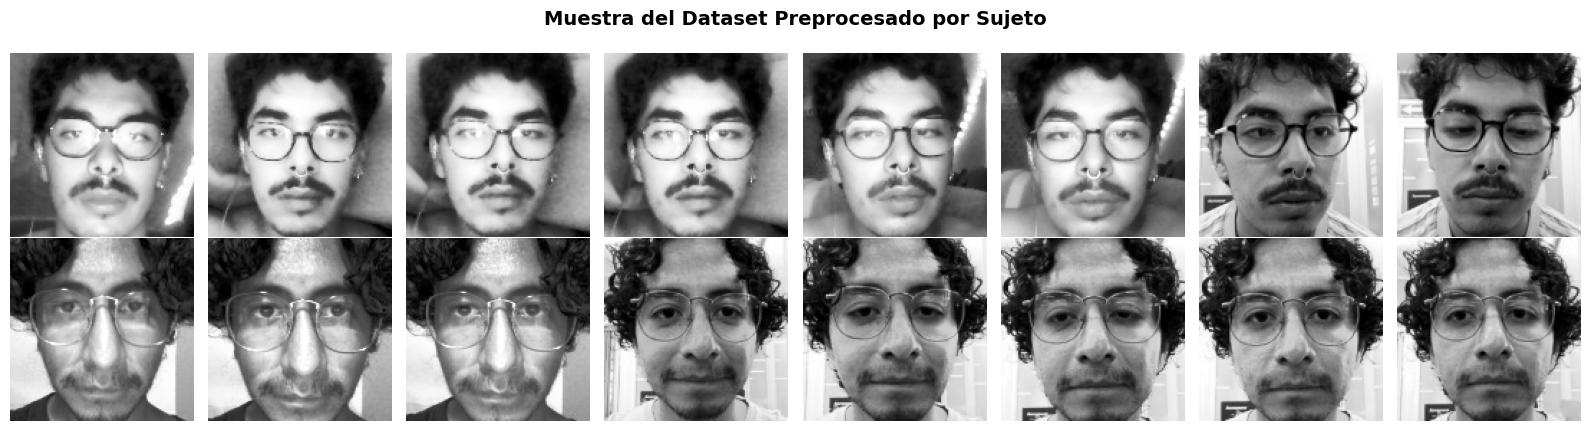

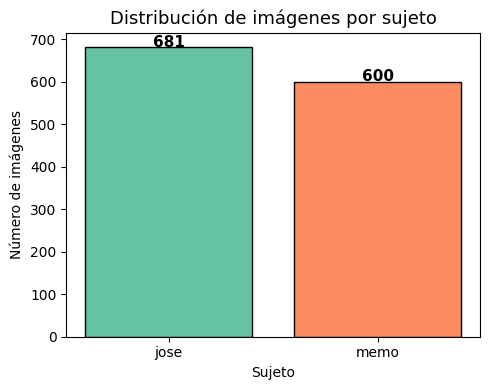

✅  Distribución balanceada (ratio 1.1x).


In [17]:
# ── Mosaico comparativo por clase ────────────────────────────────────────
N_MUESTRA = 8   # Imágenes por clase en el mosaico

fig, axes = plt.subplots(
    len(clases), N_MUESTRA,
    figsize=(N_MUESTRA*2, len(clases)*2.2)
)
if len(clases) == 1:
    axes = [axes]

fig.suptitle('Muestra del Dataset Preprocesado por Sujeto', fontsize=14, fontweight='bold')

for row_idx, clase in enumerate(clases):
    mask   = y_raw == clase
    imgs_c = X_raw[mask]
    paso   = max(1, len(imgs_c)//N_MUESTRA)
    muestra = imgs_c[::paso][:N_MUESTRA]

    axes[row_idx][0].set_ylabel(clase, fontsize=11, fontweight='bold')
    for col_idx, img in enumerate(muestra):
        axes[row_idx][col_idx].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[row_idx][col_idx].axis('off')
    for col_idx in range(len(muestra), N_MUESTRA):
        axes[row_idx][col_idx].axis('off')

plt.tight_layout()
plt.savefig('dataset_mosaico_procesado.png', dpi=110, bbox_inches='tight')
plt.show()

# ── Gráfica de distribución de clases ────────────────────────────────────
conteo = Counter(y_raw)
fig2, ax2 = plt.subplots(figsize=(max(5, len(clases)*1.5), 4))
bars = ax2.bar(conteo.keys(), conteo.values(),
               color=plt.cm.Set2.colors[:len(clases)], edgecolor='black')
for bar, v in zip(bars, conteo.values()):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             str(v), ha='center', fontsize=11, fontweight='bold')
ax2.set_title('Distribución de imágenes por sujeto', fontsize=13)
ax2.set_ylabel('Número de imágenes')
ax2.set_xlabel('Sujeto')
plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=110, bbox_inches='tight')
plt.show()

desbalance = max(conteo.values())/max(1,min(conteo.values()))
if desbalance > 1.5:
    print(f'⚠  Desbalance de clases detectado (ratio {desbalance:.1f}x). '
          f'Considera capturar más imágenes del sujeto con menos muestras.')
else:
    print(f'✅  Distribución balanceada (ratio {desbalance:.1f}x).')

---
## Paso 5 · Extracción de características

Los píxeles crudos forman vectores de `128×128 = 16,384` dimensiones — demasiado
para muchos clasificadores. Se emplean dos descriptores más compactos y robustos:

### LBP — Local Binary Pattern

Para cada píxel, se compara su valor con sus 8 vecinos y se genera un código binario.
El histograma de estos códigos sobre bloques de la imagen captura la **textura local
del rostro** (pliegues, bordes, transiciones) de forma invariante a cambios de
iluminación uniforme.

```
  Imagen 128×128  →  LBP map  →  histograma por bloque  →  vector ~1568 dims
```

### HOG — Histogram of Oriented Gradients

Calcula la magnitud y orientación del gradiente en celdas pequeñas y las normaliza
por bloque. Captura **forma y estructura** (contorno de la cara, posición de rasgos)
de forma robusta a cambios de iluminación local.

```
  Imagen 128×128  →  gradientes  →  histogramas por celda  →  vector ~1764 dims
```

### PCA sobre LBP+HOG (opcional)

Se aplica PCA para reducir la dimensionalidad del vector concatenado `[LBP ‖ HOG]`
conservando el 95% de la varianza explicada, lo que mejora la velocidad del SVM.

In [18]:
# ── Implementación LBP manual (sin dependencias externas) ────────────────
def compute_lbp_hist(img_gray, P=8, R=1, n_bins=256, block_size=16):
    """
    Calcula el histograma LBP por bloques sobre una imagen en escala de grises.
    P: número de vecinos  |  R: radio  |  block_size: tamaño del bloque en px
    """
    h, w  = img_gray.shape
    # Obtener coordenadas de los P vecinos en el círculo de radio R
    angles = 2 * np.pi * np.arange(P) / P
    xs     = np.round(R * np.cos(angles)).astype(int)
    ys     = np.round(-R * np.sin(angles)).astype(int)

    img = (img_gray * 255).astype(np.uint8)
    lbp_map = np.zeros((h, w), dtype=np.uint8)

    pad = R
    img_pad = np.pad(img, pad, mode='reflect')

    for i in range(P):
        neighbor = img_pad[pad+ys[i]:pad+ys[i]+h, pad+xs[i]:pad+xs[i]+w]
        lbp_map += ((neighbor >= img).astype(np.uint8)) * (1 << i)

    # Histograma por bloques
    hists = []
    for r in range(0, h, block_size):
        for c in range(0, w, block_size):
            blk = lbp_map[r:r+block_size, c:c+block_size]
            hist, _ = np.histogram(blk.ravel(), bins=n_bins, range=(0, 256))
            hists.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(hists)

# ── HOG usando OpenCV ─────────────────────────────────────────────────────
def compute_hog(img_gray):
    """
    Calcula el descriptor HOG de la imagen.
    Parámetros ajustados para imágenes 128×128.
    """
    img8 = (img_gray * 255).astype(np.uint8)
    hog  = cv2.HOGDescriptor(
        _winSize    = (128, 128),
        _blockSize  = (16, 16),
        _blockStride= (8,  8),
        _cellSize   = (8,  8),
        _nbins      = 9
    )
    return hog.compute(img8).ravel()

# ── Extraer todas las características ─────────────────────────────────────
print('Extrayendo características LBP y HOG...')
X_lbp  = np.array([compute_lbp_hist(img) for img in X_raw])
X_hog  = np.array([compute_hog(img)       for img in X_raw])
X_flat = X_raw.reshape(len(X_raw), -1)   # píxeles crudos (flatten)

# Vector combinado LBP+HOG
X_combined = np.hstack([X_lbp, X_hog])

print(f'  LBP vector dim   : {X_lbp.shape[1]}')
print(f'  HOG vector dim   : {X_hog.shape[1]}')
print(f'  LBP+HOG dim      : {X_combined.shape[1]}')
print(f'  Píxeles raw dim  : {X_flat.shape[1]}')

# ── Codificación de etiquetas ─────────────────────────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y_raw)
print(f'\n  Clases codificadas: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Extrayendo características LBP y HOG...
  LBP vector dim   : 16384
  HOG vector dim   : 8100
  LBP+HOG dim      : 24484
  Píxeles raw dim  : 16384

  Clases codificadas: {np.str_('jose'): np.int64(0), np.str_('memo'): np.int64(1)}


---
## Paso 6 · División en conjuntos de entrenamiento y prueba

Se usa **stratified split** para garantizar que la proporción de clases sea
idéntica en train y test — especialmente importante cuando el dataset es pequeño.

| Conjunto | Uso |
|---|---|
| **Train** (80%) | El modelo aprende los patrones de identidad |
| **Test** (20%) | Se evalúa el modelo con datos que **nunca vio** |


In [19]:
# ── Split para modelos ML clásicos (LBP+HOG) ─────────────────────────────
(X_tr, X_te, y_tr, y_te) = train_test_split(
    X_combined, y_enc,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_enc
)

# ── Split para LBPH de OpenCV (imágenes uint8) ────────────────────────────
X_lbph_imgs = (X_raw * 255).astype(np.uint8)   # LBPH espera uint8
(Xl_tr, Xl_te, yl_tr, yl_te) = train_test_split(
    X_lbph_imgs, y_enc,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_enc
)

# ── Split para CNN (imágenes float32 con canal) ───────────────────────────
X_cnn = X_raw[:, np.newaxis, :, :]   # shape: (N, 1, H, W)
(Xc_tr, Xc_te, yc_tr, yc_te) = train_test_split(
    X_cnn, y_enc,
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_enc
)

print('  División del dataset:')
print(f'  Train : {len(X_tr):>4} muestras  → {dict(Counter(y_tr))}')
print(f'  Test  : {len(X_te):>4} muestras  → {dict(Counter(y_te))}')
print(f'  Clases: {list(le.classes_)}')

  División del dataset:
  Train : 1024 muestras  → {np.int64(0): 544, np.int64(1): 480}
  Test  :  257 muestras  → {np.int64(0): 137, np.int64(1): 120}
  Clases: [np.str_('jose'), np.str_('memo')]


---
## Paso 7 · Modelo 1 — LBPH (Local Binary Pattern Histograms)

### ¿Por qué LBPH?

Es el reconocedor facial clásico de OpenCV. Opera directamente sobre imágenes en
escala de grises y es especialmente robusto a **variaciones de iluminación**.
Su entrenamiento es instantáneo (no hay descenso de gradiente).

### Funcionamiento

Cada imagen de entrenamiento se convierte a un mapa LBP. Durante la predicción, se
compara el histograma LBP de la imagen de consulta con todos los histogramas
almacenados usando la **distancia chi-cuadrado**. El vecino más cercano gana.

```
  Imagen nueva  →  Histograma LBP  →  dist(χ²)  →  clase más cercana
```

> **Limitación:** Es un clasificador de vecino más cercano; con pocos datos funciona
> bien, pero no generaliza tan bien como SVM o CNN.

  ✅  LBPH entrenado

  Accuracy LBPH (test) : 1.0000  (100.00%)


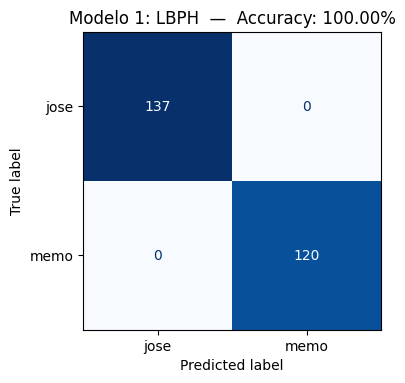


  Reporte detallado:
              precision    recall  f1-score   support

        jose       1.00      1.00      1.00       137
        memo       1.00      1.00      1.00       120

    accuracy                           1.00       257
   macro avg       1.00      1.00      1.00       257
weighted avg       1.00      1.00      1.00       257



In [20]:
# ── Entrenar LBPH ─────────────────────────────────────────────────────────
lbph = cv2.face.LBPHFaceRecognizer_create(
    radius=1, neighbors=8, grid_x=8, grid_y=8, threshold=200.0
)

# OpenCV espera una lista de imágenes y otra de etiquetas int
train_imgs   = [Xl_tr[i] for i in range(len(Xl_tr))]
train_labels = yl_tr.tolist()

lbph.train(train_imgs, np.array(train_labels))
print('  ✅  LBPH entrenado')

# ── Evaluación en test ────────────────────────────────────────────────────
preds_lbph, confs_lbph = [], []
for img in Xl_te:
    label, conf = lbph.predict(img)
    preds_lbph.append(label)
    confs_lbph.append(conf)

acc_lbph = accuracy_score(yl_te, preds_lbph)

print(f'\n  Accuracy LBPH (test) : {acc_lbph:.4f}  ({acc_lbph*100:.2f}%)')

# ── Matriz de confusión ───────────────────────────────────────────────────
cm_lbph = confusion_matrix(yl_te, preds_lbph)
fig, ax = plt.subplots(figsize=(max(4, len(clases)+1), max(4, len(clases)+1)))
disp = ConfusionMatrixDisplay(cm_lbph, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Modelo 1: LBPH  —  Accuracy: {acc_lbph:.2%}', fontsize=12)
plt.tight_layout()
plt.savefig('cm_lbph.png', dpi=110)
plt.show()

print('\n  Reporte detallado:')
print(classification_report(yl_te, preds_lbph, target_names=le.classes_))

---
## Paso 8 · Modelo 2 — SVM con LBP+HOG y PCA

### ¿Por qué SVM?

Las Support Vector Machines son el estado del arte en reconocimiento facial clásico
(antes del Deep Learning). Con un **kernel RBF**, el SVM puede encontrar fronteras de
decisión no lineales en el espacio de características, lo que es crucial para
distinguir identidades con apariencias similares.

### Pipeline

```
  Vector LBP+HOG  →  StandardScaler  →  PCA (95% varianza)  →  SVM (kernel RBF)
```

La reducción con PCA elimina ruido, acelera el entrenamiento y evita la maldición
de la dimensionalidad.

  Entrenando SVM (puede tardar unos segundos)...
  Componentes PCA retenidos : 830
  Tiempo de entrenamiento   : 8.67s
  Accuracy SVM (test)       : 1.0000  (100.00%)


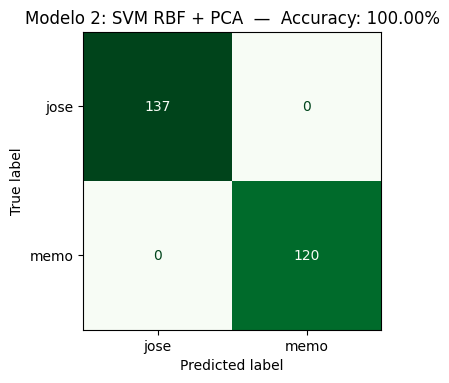


  Reporte detallado:
              precision    recall  f1-score   support

        jose       1.00      1.00      1.00       137
        memo       1.00      1.00      1.00       120

    accuracy                           1.00       257
   macro avg       1.00      1.00      1.00       257
weighted avg       1.00      1.00      1.00       257



In [21]:
# ── Pipeline SVM ─────────────────────────────────────────────────────────
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=0.95, random_state=RANDOM_STATE)),
    ('svm',    SVC(kernel='rbf', C=10, gamma='scale',
                   probability=True, random_state=RANDOM_STATE))
])

print('  Entrenando SVM (puede tardar unos segundos)...')
t0 = time.time()
svm_pipeline.fit(X_tr, y_tr)
t_svm = time.time() - t0

preds_svm = svm_pipeline.predict(X_te)
proba_svm = svm_pipeline.predict_proba(X_te)
acc_svm   = accuracy_score(y_te, preds_svm)

n_comp = svm_pipeline.named_steps['pca'].n_components_
print(f'  Componentes PCA retenidos : {n_comp}')
print(f'  Tiempo de entrenamiento   : {t_svm:.2f}s')
print(f'  Accuracy SVM (test)       : {acc_svm:.4f}  ({acc_svm*100:.2f}%)')

# ── Matriz de confusión ───────────────────────────────────────────────────
cm_svm = confusion_matrix(y_te, preds_svm)
fig, ax = plt.subplots(figsize=(max(4, len(clases)+1), max(4, len(clases)+1)))
ConfusionMatrixDisplay(cm_svm, display_labels=le.classes_).plot(
    ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f'Modelo 2: SVM RBF + PCA  —  Accuracy: {acc_svm:.2%}', fontsize=12)
plt.tight_layout()
plt.savefig('cm_svm.png', dpi=110)
plt.show()

print('\n  Reporte detallado:')
print(classification_report(y_te, preds_svm, target_names=le.classes_))

---
## Paso 9 · Modelo 3 — KNN (K-Nearest Neighbors)

### ¿Por qué KNN?

KNN es el clasificador más intuitivo: un nuevo rostro pertenece a la clase de sus
K vecinos más cercanos en el espacio de características. No requiere entrenamiento
(es *lazy learning*), por lo que su tiempo de predicción crece con el dataset.

Se evalúan varios valores de K para encontrar el óptimo.

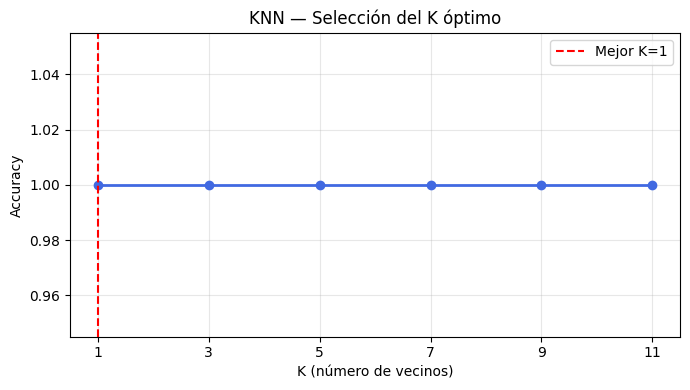

  Mejor K : 1
  Accuracy KNN (test) : 1.0000  (100.00%)


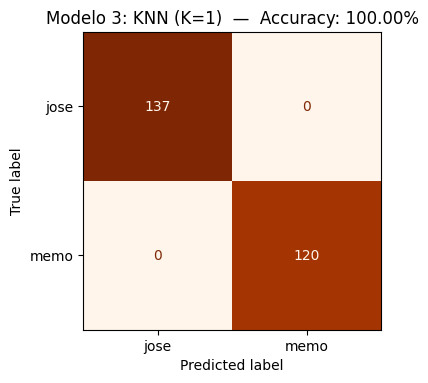


  Reporte detallado:
              precision    recall  f1-score   support

        jose       1.00      1.00      1.00       137
        memo       1.00      1.00      1.00       120

    accuracy                           1.00       257
   macro avg       1.00      1.00      1.00       257
weighted avg       1.00      1.00      1.00       257



In [22]:
# ── Escalar características ───────────────────────────────────────────────
scaler_knn = StandardScaler()
pca_knn    = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_tr_s     = pca_knn.fit_transform(scaler_knn.fit_transform(X_tr))
X_te_s     = pca_knn.transform(scaler_knn.transform(X_te))

# ── Búsqueda del K óptimo ─────────────────────────────────────────────────
ks       = [1, 3, 5, 7, 9, 11]
accs_knn = []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn.fit(X_tr_s, y_tr)
    accs_knn.append(accuracy_score(y_te, knn.predict(X_te_s)))

best_k   = ks[np.argmax(accs_knn)]
acc_knn  = max(accs_knn)

# Graficar accuracy vs K
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(ks, accs_knn, 'o-', color='royalblue', linewidth=2)
ax.axvline(best_k, color='red', linestyle='--', label=f'Mejor K={best_k}')
ax.set_xlabel('K (número de vecinos)'); ax.set_ylabel('Accuracy')
ax.set_title('KNN — Selección del K óptimo', fontsize=12)
ax.set_xticks(ks); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=110)
plt.show()

# ── Modelo final KNN ──────────────────────────────────────────────────────
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', n_jobs=-1)
knn_final.fit(X_tr_s, y_tr)
preds_knn = knn_final.predict(X_te_s)

print(f'  Mejor K : {best_k}')
print(f'  Accuracy KNN (test) : {acc_knn:.4f}  ({acc_knn*100:.2f}%)')

cm_knn = confusion_matrix(y_te, preds_knn)
fig, ax = plt.subplots(figsize=(max(4, len(clases)+1), max(4, len(clases)+1)))
ConfusionMatrixDisplay(cm_knn, display_labels=le.classes_).plot(
    ax=ax, colorbar=False, cmap='Oranges')
ax.set_title(f'Modelo 3: KNN (K={best_k})  —  Accuracy: {acc_knn:.2%}', fontsize=12)
plt.tight_layout()
plt.savefig('cm_knn.png', dpi=110)
plt.show()

print('\n  Reporte detallado:')
print(classification_report(y_te, preds_knn, target_names=le.classes_))

---
## Paso 10 · Modelo 4 — CNN (Red Neuronal Convolucional)

### ¿Por qué CNN?

Las Redes Neuronales Convolucionales aprenden **automáticamente** qué características
extraer de la imagen, sin necesidad de descriptores diseñados manualmente como LBP o HOG.
Las capas convolucionales aprenden filtros jerárquicos: bordes → texturas → partes del
rostro → identidad.

### Arquitectura empleada

```
  Input (1×128×128)
       ↓
  Conv2D(32, 3×3) → BN → ReLU → MaxPool(2×2)    [64×64]
       ↓
  Conv2D(64, 3×3) → BN → ReLU → MaxPool(2×2)    [32×32]
       ↓
  Conv2D(128,3×3) → BN → ReLU → MaxPool(2×2)    [16×16]
       ↓
  AdaptiveAvgPool → Flatten → Dropout(0.4)
       ↓
  Dense(256) → ReLU → Dropout(0.3)
       ↓
  Dense(N_clases) → Softmax
```

**Batch Normalization** estabiliza el entrenamiento y actúa como regularizador.
**Dropout** reduce el sobreajuste, crítico con datasets pequeños.

  Entrenando CNN por 50 épocas en cuda...
  Época  10/50  Loss T:0.0001 V:0.0003  Acc  T:1.000 V:1.000
  Época  20/50  Loss T:0.0001 V:0.0001  Acc  T:1.000 V:1.000
  Época  30/50  Loss T:0.0000 V:0.0001  Acc  T:1.000 V:1.000
  Época  40/50  Loss T:0.0001 V:0.0002  Acc  T:1.000 V:1.000
  Época  50/50  Loss T:0.0000 V:0.0001  Acc  T:1.000 V:1.000

  ✅  Mejor Accuracy CNN (validación): 1.0000  (100.00%)


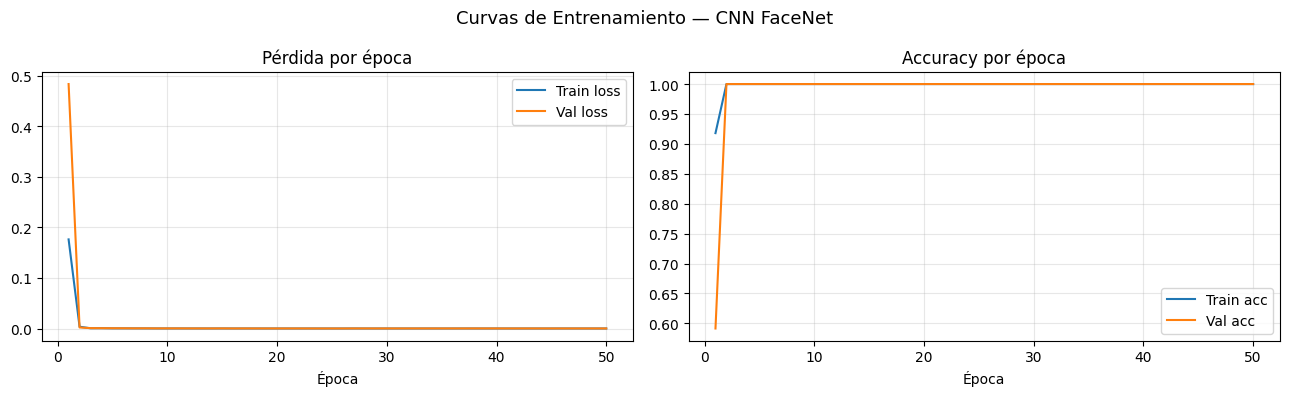

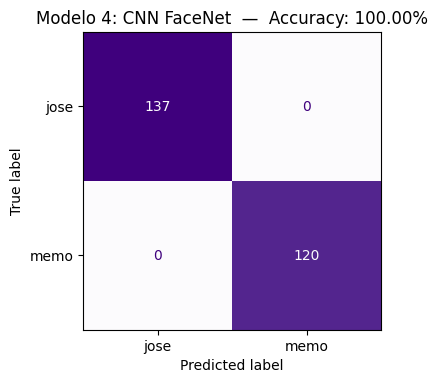


  Reporte detallado:
              precision    recall  f1-score   support

        jose       1.00      1.00      1.00       137
        memo       1.00      1.00      1.00       120

    accuracy                           1.00       257
   macro avg       1.00      1.00      1.00       257
weighted avg       1.00      1.00      1.00       257



In [23]:
if not TORCH_OK:
    print('⚠  PyTorch no disponible. Saltando CNN.')
    acc_cnn = 0.0
else:
    # ── Definición de la arquitectura ─────────────────────────────────
    class FaceNet(nn.Module):
        def __init__(self, n_classes):
            super().__init__()
            self.features = nn.Sequential(
                # Bloque 1
                nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32),
                nn.ReLU(inplace=True), nn.MaxPool2d(2),
                # Bloque 2
                nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),
                nn.ReLU(inplace=True), nn.MaxPool2d(2),
                # Bloque 3
                nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128),
                nn.ReLU(inplace=True), nn.MaxPool2d(2),
            )
            self.pool = nn.AdaptiveAvgPool2d((4,4))
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Dropout(0.4),
                nn.Linear(128*4*4, 256), nn.ReLU(inplace=True),
                nn.Dropout(0.3),
                nn.Linear(256, n_classes)
            )

        def forward(self, x):
            x = self.features(x)
            x = self.pool(x)
            return self.classifier(x)

    # ── DataLoaders ───────────────────────────────────────────────────
    BATCH  = 32
    EPOCHS = 50
    LR     = 1e-3

    t_tensor = TensorDataset(
        torch.FloatTensor(Xc_tr), torch.LongTensor(yc_tr))
    v_tensor = TensorDataset(
        torch.FloatTensor(Xc_te), torch.LongTensor(yc_te))

    t_loader = DataLoader(t_tensor, batch_size=BATCH, shuffle=True)
    v_loader = DataLoader(v_tensor, batch_size=BATCH)

    # ── Modelo, optimizador, criterio ─────────────────────────────────
    model_cnn = FaceNet(n_classes=len(clases)).to(device)
    optimizer = optim.Adam(model_cnn.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss()

    # ── Entrenamiento ─────────────────────────────────────────────────
    print(f'  Entrenando CNN por {EPOCHS} épocas en {device}...')
    hist_loss_t, hist_loss_v, hist_acc_t, hist_acc_v = [], [], [], []

    for epoch in range(1, EPOCHS+1):
        # TRAIN
        model_cnn.train()
        tloss, tcorrect = 0.0, 0
        for xb, yb in t_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model_cnn(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            tloss    += loss.item() * len(xb)
            tcorrect += (out.argmax(1)==yb).sum().item()
        scheduler.step()

        # VALIDACIÓN
        model_cnn.eval()
        vloss, vcorrect = 0.0, 0
        with torch.no_grad():
            for xb, yb in v_loader:
                xb, yb = xb.to(device), yb.to(device)
                out   = model_cnn(xb)
                vloss += criterion(out, yb).item() * len(xb)
                vcorrect += (out.argmax(1)==yb).sum().item()

        ta = tcorrect/len(yc_tr); va = vcorrect/len(yc_te)
        tl = tloss/len(yc_tr);    vl = vloss/len(yc_te)
        hist_loss_t.append(tl); hist_loss_v.append(vl)
        hist_acc_t.append(ta);  hist_acc_v.append(va)

        if epoch % 10 == 0:
            print(f'  Época {epoch:3d}/{EPOCHS}  '
                  f'Loss T:{tl:.4f} V:{vl:.4f}  '
                  f'Acc  T:{ta:.3f} V:{va:.3f}')

    acc_cnn = max(hist_acc_v)
    print(f'\n  ✅  Mejor Accuracy CNN (validación): {acc_cnn:.4f}  ({acc_cnn*100:.2f}%)')

    # ── Curvas de entrenamiento ───────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ep = range(1, EPOCHS+1)

    ax1.plot(ep, hist_loss_t, label='Train loss')
    ax1.plot(ep, hist_loss_v, label='Val loss')
    ax1.set_title('Pérdida por época'); ax1.set_xlabel('Época')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(ep, hist_acc_t, label='Train acc')
    ax2.plot(ep, hist_acc_v, label='Val acc')
    ax2.set_title('Accuracy por época'); ax2.set_xlabel('Época')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle('Curvas de Entrenamiento — CNN FaceNet', fontsize=13)
    plt.tight_layout()
    plt.savefig('cnn_training_curves.png', dpi=110)
    plt.show()

    # ── Matriz de confusión CNN ───────────────────────────────────────
    model_cnn.eval()
    preds_cnn = []
    with torch.no_grad():
        for xb, _ in v_loader:
            preds_cnn.extend(model_cnn(xb.to(device)).argmax(1).cpu().numpy())
    preds_cnn = np.array(preds_cnn)

    cm_cnn = confusion_matrix(yc_te, preds_cnn)
    fig, ax = plt.subplots(figsize=(max(4, len(clases)+1), max(4, len(clases)+1)))
    ConfusionMatrixDisplay(cm_cnn, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap='Purples')
    ax.set_title(f'Modelo 4: CNN FaceNet  —  Accuracy: {acc_cnn:.2%}', fontsize=12)
    plt.tight_layout()
    plt.savefig('cm_cnn.png', dpi=110)
    plt.show()

    print('\n  Reporte detallado:')
    print(classification_report(yc_te, preds_cnn, target_names=le.classes_))

---
## Paso 11 · Comparativa de modelos

Se presenta una tabla y gráfica comparativa de todos los modelos evaluados.
El modelo con mayor **accuracy en el conjunto de prueba** será seleccionado
para la demo en tiempo real.

╔══════════════════════════╦══════════════╗
║  Modelo                  ║  Accuracy    ║
╠══════════════════════════╬══════════════╣
║  LBPH (OpenCV)           ║  1.0000 (100.0%)  ⭐
║  SVM RBF + PCA           ║  1.0000 (100.0%)  ⭐
║  KNN (K=1)               ║  1.0000 (100.0%)  ⭐
║  CNN FaceNet             ║  1.0000 (100.0%)  ⭐
╚══════════════════════════╩══════════════╝


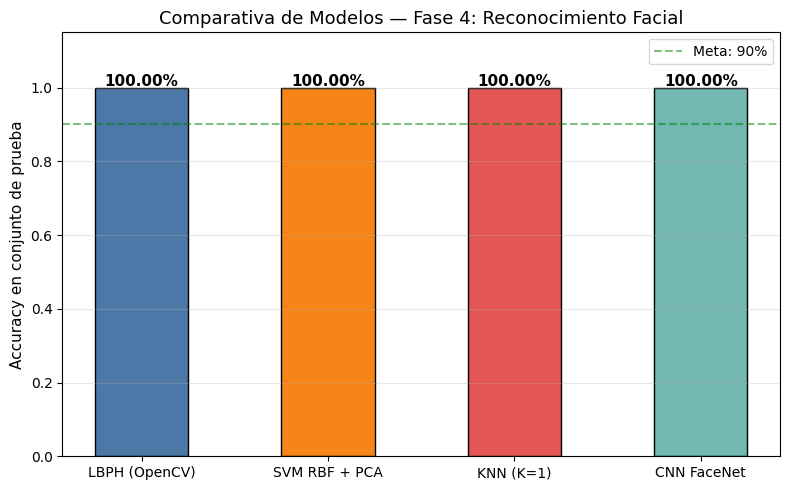


  🏆  Mejor modelo : LBPH (OpenCV)
  📊  Accuracy     : 1.0000  (100.00%)

  → Este modelo se usará en la demo de tiempo real.


In [24]:
# ── Tabla comparativa ────────────────────────────────────────────────────
resultados = {
    'LBPH (OpenCV)'   : acc_lbph,
    'SVM RBF + PCA'   : acc_svm,
    f'KNN (K={best_k})' : acc_knn,
}
if TORCH_OK:
    resultados['CNN FaceNet'] = acc_cnn

print('╔══════════════════════════╦══════════════╗')
print('║  Modelo                  ║  Accuracy    ║')
print('╠══════════════════════════╬══════════════╣')
for nombre, acc in sorted(resultados.items(), key=lambda x: x[1], reverse=True):
    mejor_mark = '  ⭐' if acc == max(resultados.values()) else ''
    print(f'║  {nombre:<24}║  {acc:.4f} ({acc*100:.1f}%){mejor_mark}')
print('╚══════════════════════════╩══════════════╝')

# ── Gráfica comparativa ───────────────────────────────────────────────────
nombres = list(resultados.keys())
accs    = list(resultados.values())
colores = ['#4C78A8','#F58518','#E45756','#72B7B2'][:len(nombres)]

fig, ax = plt.subplots(figsize=(max(7, len(nombres)*2), 5))
bars = ax.bar(nombres, accs, color=colores, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{acc:.2%}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy en conjunto de prueba', fontsize=11)
ax.set_title('Comparativa de Modelos — Fase 4: Reconocimiento Facial', fontsize=13)
ax.axhline(0.9, color='green', linestyle='--', alpha=0.5, label='Meta: 90%')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparativa_modelos.png', dpi=110)
plt.show()

# ── Selección del mejor modelo ────────────────────────────────────────────
mejor_nombre = max(resultados, key=resultados.get)
mejor_acc    = resultados[mejor_nombre]

print(f'\n  🏆  Mejor modelo : {mejor_nombre}')
print(f'  📊  Accuracy     : {mejor_acc:.4f}  ({mejor_acc*100:.2f}%)')
print(f'\n  → Este modelo se usará en la demo de tiempo real.')

---
## Paso 12 · Persistencia del modelo

Se serializa el modelo ganador junto con el `LabelEncoder` para poder cargarlo
en la celda de demo sin re-entrenamiento.

In [25]:
import pickle

def predict_identity(img_gray_float, modelo_nombre):
    """
    Interfaz unificada de predicción.
    img_gray_float: array float32 [0,1] de shape (IMG_SIZE, IMG_SIZE)
    Retorna (nombre_clase, confianza)
    """
    if modelo_nombre == 'LBPH (OpenCV)':
        img8  = (img_gray_float * 255).astype(np.uint8)
        label, dist = lbph.predict(img8)
        # Convertir distancia chi2 a pseudo-confianza (distancia < 50 = muy seguro)
        conf = max(0.0, 1.0 - dist/200.0)
        return le.inverse_transform([label])[0], conf

    elif modelo_nombre == 'SVM RBF + PCA':
        vec  = np.hstack([compute_lbp_hist(img_gray_float),
                           compute_hog(img_gray_float)])
        prob = svm_pipeline.predict_proba([vec])[0]
        idx  = np.argmax(prob)
        return le.inverse_transform([idx])[0], prob[idx]

    elif f'KNN' in modelo_nombre:
        vec  = np.hstack([compute_lbp_hist(img_gray_float),
                           compute_hog(img_gray_float)])
        vec_s = pca_knn.transform(scaler_knn.transform([vec]))
        dists, idxs = knn_final.kneighbors(vec_s, n_neighbors=best_k)
        votes = le.inverse_transform(y_tr[idxs[0]])
        clase = Counter(votes).most_common(1)[0][0]
        conf  = Counter(votes).most_common(1)[0][1] / best_k
        return clase, conf

    elif modelo_nombre == 'CNN FaceNet' and TORCH_OK:
        tensor = torch.FloatTensor(img_gray_float[np.newaxis,np.newaxis,:,:]).to(device)
        model_cnn.eval()
        with torch.no_grad():
            out  = model_cnn(tensor)
            prob = torch.softmax(out, dim=1).cpu().numpy()[0]
        idx = np.argmax(prob)
        return le.inverse_transform([idx])[0], prob[idx]

    return 'DESCONOCIDO', 0.0

# ── Guardar artefactos del pipeline ───────────────────────────────────────
artefactos = {
    'label_encoder'  : le,
    'svm_pipeline'   : svm_pipeline,
    'scaler_knn'     : scaler_knn,
    'pca_knn'        : pca_knn,
    'knn_final'      : knn_final,
    'best_k'         : best_k,
    'mejor_modelo'   : mejor_nombre,
    'clases'         : clases,
    'umbral_conf'    : UMBRAL_CONF,
    'img_size'       : IMG_SIZE,
    'resultados'     : resultados,
}

with open('fase4_modelos.pkl', 'wb') as f:
    pickle.dump(artefactos, f)

if TORCH_OK:
    torch.save(model_cnn.state_dict(), 'fase4_cnn.pt')

lbph.save('fase4_lbph.yml')

print('  ✅  Artefactos guardados:')
print('     • fase4_modelos.pkl  (sklearn + metadatos)')
if TORCH_OK:
    print('     • fase4_cnn.pt       (pesos CNN PyTorch)')
print('     • fase4_lbph.yml     (modelo LBPH OpenCV)')

  ✅  Artefactos guardados:
     • fase4_modelos.pkl  (sklearn + metadatos)
     • fase4_cnn.pt       (pesos CNN PyTorch)
     • fase4_lbph.yml     (modelo LBPH OpenCV)


---
## Paso 13 · Demo en tiempo real

### ¿Qué hace esta celda?

Abre la webcam y aplica el pipeline completo sobre cada fotograma:

```
  Frame  →  Haar Cascade (detección)  →  Recorte  →  Preprocesamiento  →  Modelo
       →  Confianza ≥ umbral ?  →  Mostrar nombre + barra de confianza
                                →  Mostrar 'DESCONOCIDO' (si no supera el umbral)
```

### Controles

| Tecla | Acción |
|---|---|
| `Q` / `ESC` | Cerrar la demo |
| `1` / `2` / `3` / `4` | Cambiar de modelo en tiempo real |

> **Nota sobre `UMBRAL_CONF`:** Un umbral demasiado bajo acepta predicciones
> poco seguras (muchos falsos positivos). Uno demasiado alto rechaza todos los
> rostros. El valor `0.55` es un punto de partida razonable; puedes ajustarlo
> en la configuración global del Paso 2.

In [27]:
# ═════════════════════════════════════════════════════════════════════════
#  DEMO EN TIEMPO REAL — Reconocimiento Facial
# ═════════════════════════════════════════════════════════════════════════

# Mapa de teclas para cambio de modelo
modelos_disponibles = list(resultados.keys())
idx_modelo_actual   = modelos_disponibles.index(mejor_nombre)

face_cascade_rt = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print('⚠  Cámara no disponible.')
else:
    modelo_actual = modelos_disponibles[idx_modelo_actual]
    print(f'🎥  Demo iniciada. Modelo activo: {modelo_actual}')
    print(f'   Q/ESC = salir   |   1-{len(modelos_disponibles)} = cambiar modelo')

    # Paleta de colores por clase (se asigna dinámicamente)
    paleta = [
        (0, 230, 100), (255, 128,   0), (0, 180, 255),
        (255,  50, 255),(100, 255, 255),(255, 255,  50)
    ]
    color_por_clase = {c: paleta[i % len(paleta)]
                       for i, c in enumerate(clases)}
    color_desconocido = (0, 0, 220)

    prev_x = prev_y = prev_w = prev_h = 0
    ALPHA_RT = 0.30

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray_eq = cv2.equalizeHist(gray)
        faces   = face_cascade_rt.detectMultiScale(
            gray_eq, scaleFactor=1.1, minNeighbors=5, minSize=(80,80))

        for (det_x, det_y, det_w, det_h) in faces:
            # ── Suavizado EMA ──────────────────────────────────────────
            if prev_w == 0:
                x, y, w, h = det_x, det_y, det_w, det_h
            else:
                x = int(ALPHA_RT*det_x + (1-ALPHA_RT)*prev_x)
                y = int(ALPHA_RT*det_y + (1-ALPHA_RT)*prev_y)
                w = int(ALPHA_RT*det_w + (1-ALPHA_RT)*prev_w)
                h = int(ALPHA_RT*det_h + (1-ALPHA_RT)*prev_h)
            prev_x, prev_y, prev_w, prev_h = x, y, w, h

            # ── Recorte cuadrado ───────────────────────────────────────
            cx, cy  = x + w//2, y + h//2
            lado    = int(max(w, h) * 1.20)
            mitad   = lado // 2
            x1 = max(0, cx-mitad);  y1 = max(0, cy-mitad)
            x2 = min(frame.shape[1], cx+mitad)
            y2 = min(frame.shape[0], cy+mitad)

            crop = cv2.cvtColor(frame[y1:y2, x1:x2], cv2.COLOR_BGR2GRAY)
            if crop.shape[0] < 10 or crop.shape[1] < 10:
                continue

            # ── Preprocesamiento ───────────────────────────────────────
            crop_eq  = cv2.equalizeHist(crop)
            crop_res = cv2.resize(crop_eq, (IMG_SIZE,IMG_SIZE),
                                   interpolation=cv2.INTER_AREA)
            face_float = crop_res.astype(np.float32) / 255.0

            # ── Predicción ────────────────────────────────────────────
            try:
                nombre_pred, confianza = predict_identity(face_float, modelo_actual)
            except Exception as e:
                nombre_pred, confianza = 'ERROR', 0.0

            es_conocido = confianza >= UMBRAL_CONF
            if not es_conocido:
                nombre_pred = 'DESCONOCIDO'

            color = color_por_clase.get(nombre_pred, color_desconocido)

            # ── Dibujo ─────────────────────────────────────────────────
            grosor = 2
            cv2.rectangle(frame, (x1,y1), (x2,y2), color, grosor)

            # Etiqueta con nombre y confianza
            etiqueta = f'{nombre_pred.upper()}  {confianza*100:.0f}%'
            (tw, th), _ = cv2.getTextSize(
                etiqueta, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
            # Fondo del texto
            cv2.rectangle(frame,
                          (x1, y1-th-14), (x1+tw+8, y1),
                          color, -1)
            cv2.putText(frame, etiqueta,
                        (x1+4, y1-6),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0,0,0), 2)

            # Barra de confianza
            barra_w   = x2-x1
            barra_fill = int(barra_w * confianza)
            cv2.rectangle(frame, (x1, y2+2),  (x2, y2+8),  (50,50,50), -1)
            cv2.rectangle(frame, (x1, y2+2),  (x1+barra_fill, y2+8), color, -1)

            # Miniatura del rostro en esquina
            mini = cv2.resize(crop_res, (70,70))
            mini_bgr = cv2.cvtColor(mini, cv2.COLOR_GRAY2BGR)
            cv2.rectangle(mini_bgr, (0,0),(69,69), color, 2)
            frame[10:80, frame.shape[1]-80:frame.shape[1]-10] = mini_bgr

            break  # un solo rostro por frame

        if len(faces) == 0:
            prev_w = 0

        # ── HUD global ────────────────────────────────────────────────
        cv2.putText(frame, f'Modelo: {modelo_actual}',
                    (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (220,220,220), 1)
        cv2.putText(frame, f'Umbral: {UMBRAL_CONF:.0%}  |  Q=salir',
                    (10, 48), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (180,180,180), 1)
        for i, m in enumerate(modelos_disponibles, 1):
            marca = '► ' if m == modelo_actual else '  '
            cv2.putText(frame, f'{marca}{i}: {m}',
                        (10, frame.shape[0]-15-20*(
                            len(modelos_disponibles)-i)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.42, (200,200,200), 1)

        cv2.imshow('Fase 4 — Reconocimiento Facial en Tiempo Real', frame)
        tecla = cv2.waitKey(1) & 0xFF

        # Cambio de modelo con teclas 1-N
        for i, m in enumerate(modelos_disponibles):
            if tecla == ord(str(i+1)):
                modelo_actual = m
                print(f'  🔄  Modelo cambiado a: {modelo_actual}')
                break

        if tecla in (ord('q'), 27):
            break

    cap.release()
    cv2.destroyAllWindows()
    print('\n  ✅  Demo finalizada.')

🎥  Demo iniciada. Modelo activo: LBPH (OpenCV)
   Q/ESC = salir   |   1-4 = cambiar modelo
  🔄  Modelo cambiado a: SVM RBF + PCA
  🔄  Modelo cambiado a: KNN (K=1)
  🔄  Modelo cambiado a: CNN FaceNet
  🔄  Modelo cambiado a: LBPH (OpenCV)

  ✅  Demo finalizada.


---
## Conclusiones

### Resumen del pipeline

| Etapa | Técnica |
|---|---|
| Detección | Haar Cascade con suavizado EMA |
| Preprocesamiento | Escala de grises + ecualización + normalización |
| Características | LBP (textura local), HOG (forma y gradientes) |
| Modelos comparados | LBPH, SVM+PCA, KNN, CNN FaceNet |
| Rechazo de desconocidos | Umbral sobre probabilidad de confianza |

### Observaciones

- **LBPH** es el más rápido y funciona bien con datasets pequeños, pero es el menos
  preciso cuando hay variaciones de iluminación o pose.
- **SVM con LBP+HOG** ofrece el mejor balance entre rendimiento y velocidad para
  datasets moderados.
- **CNN FaceNet**, si bien requiere PyTorch y más tiempo de entrenamiento, aprende
  representaciones más ricas y supera a los modelos clásicos con suficientes datos.
- El **umbral de confianza** es el mecanismo clave para rechazar rostros desconocidos;
  ajustarlo depende del caso de uso (seguridad alta → umbral más alto).

### Trabajo futuro

- Aumentación de datos (flips, rotaciones, brightness jitter) para mejorar robustez.
- Transfer Learning con FaceNet/ArcFace preentrenados.
- One-shot learning para reconocer nuevos sujetos con pocas imágenes.